In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving 100_company_main.csv to 100_company_main.csv
User uploaded file "100_company_main.csv" with length 19586 bytes


Korelāciju analīze

Pearson korelāciju matrica


=== Pearson Correlation Matrix ===
                Total_ESG  Environmental  Social  Governance  MarketCap  \
Total_ESG           1.000          0.707   0.596       0.350     -0.148   
Environmental       0.707          1.000  -0.024      -0.243     -0.085   
Social              0.596         -0.024   1.000       0.331     -0.128   
Governance          0.350         -0.243   0.331       1.000     -0.043   
MarketCap          -0.148         -0.085  -0.128      -0.043      1.000   
TotalRevenue       -0.090         -0.107   0.036      -0.055      0.209   
NetIncome           0.000         -0.023  -0.031       0.088      0.672   
ReturnOnEquity     -0.003          0.050  -0.060      -0.036      0.154   
DebtToEquity        0.002          0.079  -0.120      -0.010     -0.048   
CurrentRatio       -0.115         -0.153  -0.004       0.029      0.049   
QuickRatio         -0.112         -0.199   0.036       0.083      0.132   

                TotalRevenue  NetIncome  ReturnOnEquity  DebtTo

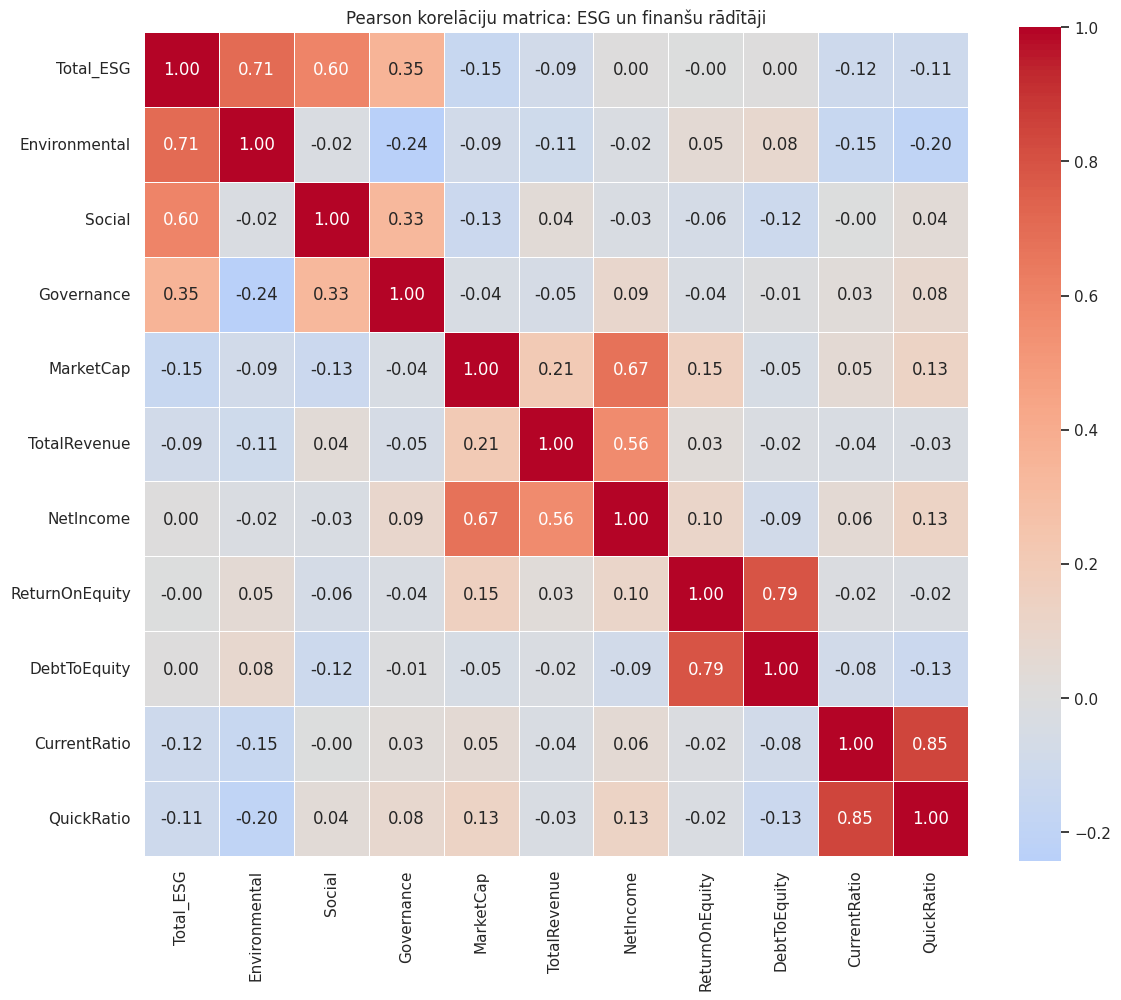

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

df = pd.read_csv("100_company_main.csv")

# Atlasām mainīgos
cols = [
    "Total_ESG",
    "Environmental",
    "Social",
    "Governance",
    "MarketCap",
    "TotalRevenue",
    "NetIncome",
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio"
]

corr_matrix = df[cols].corr(method="pearson")

print("\n=== Pearson Correlation Matrix ===")
print(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Pearson korelāciju matrica: ESG un finanšu rādītāji")
plt.tight_layout()

plt.savefig("correlation_heatmap_pearson.pdf", format="pdf", bbox_inches="tight")
print("\nSaglabāts: correlation_heatmap_pearson.pdf")

plt.show()


Spearman korelācija


=== Spearman Correlation Matrix ===
                Total_ESG  Environmental  Social  Governance  MarketCap  \
Total_ESG           1.000          0.469   0.620       0.409     -0.219   
Environmental       0.469          1.000  -0.192      -0.310     -0.124   
Social              0.620         -0.192   1.000       0.348     -0.043   
Governance          0.409         -0.310   0.348       1.000     -0.175   
MarketCap          -0.219         -0.124  -0.043      -0.175      1.000   
TotalRevenue       -0.153         -0.091  -0.086      -0.166      0.490   
NetIncome          -0.050         -0.069   0.001       0.007      0.552   
ReturnOnEquity     -0.097          0.074  -0.144      -0.062      0.259   
DebtToEquity       -0.201          0.140  -0.294      -0.293     -0.046   
CurrentRatio       -0.048         -0.127   0.056       0.084     -0.121   
QuickRatio          0.006         -0.125   0.091       0.134     -0.086   

                TotalRevenue  NetIncome  ReturnOnEquity  DebtT

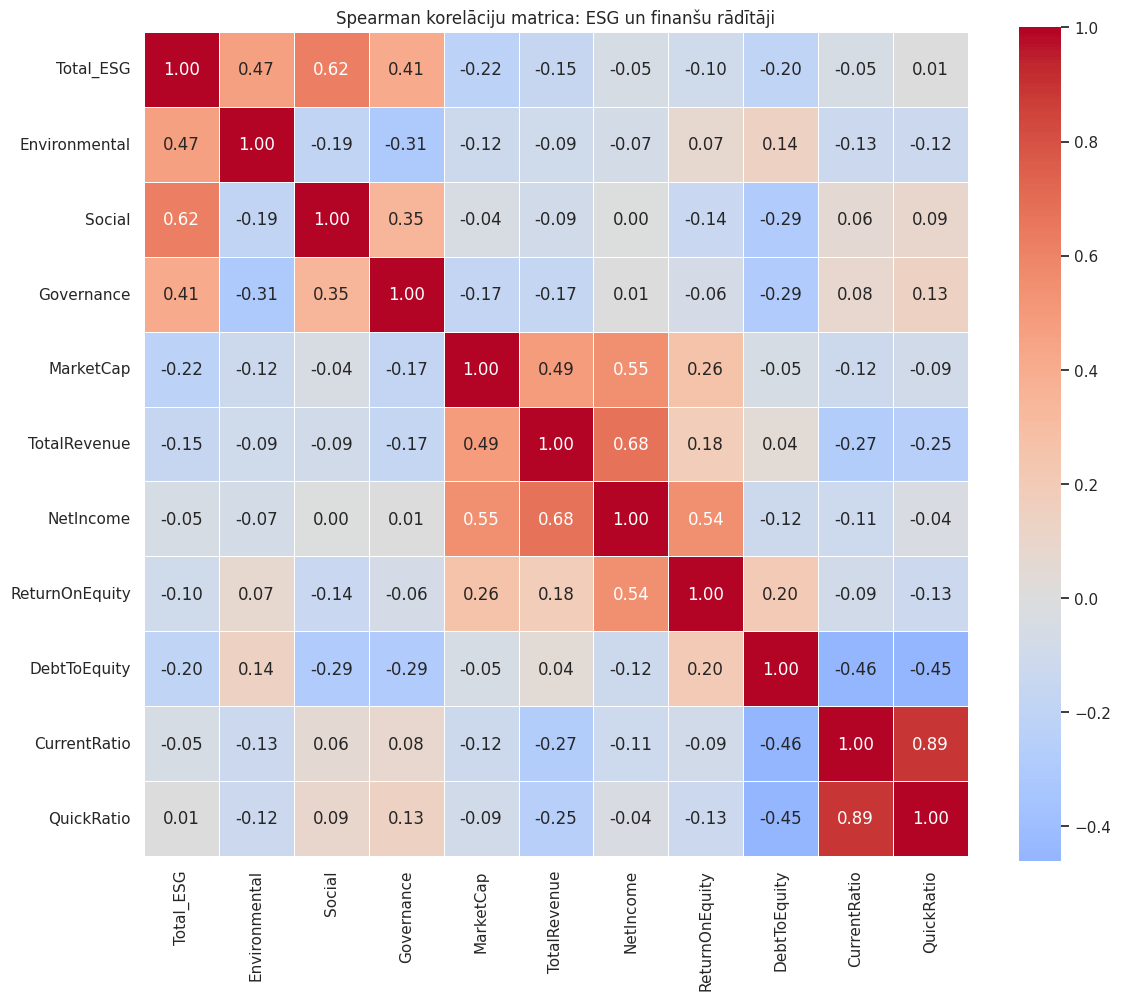

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

df = pd.read_csv("100_company_main.csv")

cols = [
    "Total_ESG",
    "Environmental",
    "Social",
    "Governance",
    "MarketCap",
    "TotalRevenue",
    "NetIncome",
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio"
]

spearman_corr = df[cols].corr(method="spearman")

print("\n=== Spearman Correlation Matrix ===")
print(spearman_corr.round(3))

plt.figure(figsize=(12,10))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Spearman korelāciju matrica: ESG un finanšu rādītāji")
plt.tight_layout()

plt.savefig("correlation_heatmap_spearman.pdf", format="pdf", bbox_inches="tight")
print("\nSaglabāts: correlation_heatmap_spearman.pdf")

plt.show()


Papildu pārbaude - pēc Sektora

Industrials uzņēmumu skaits: 12


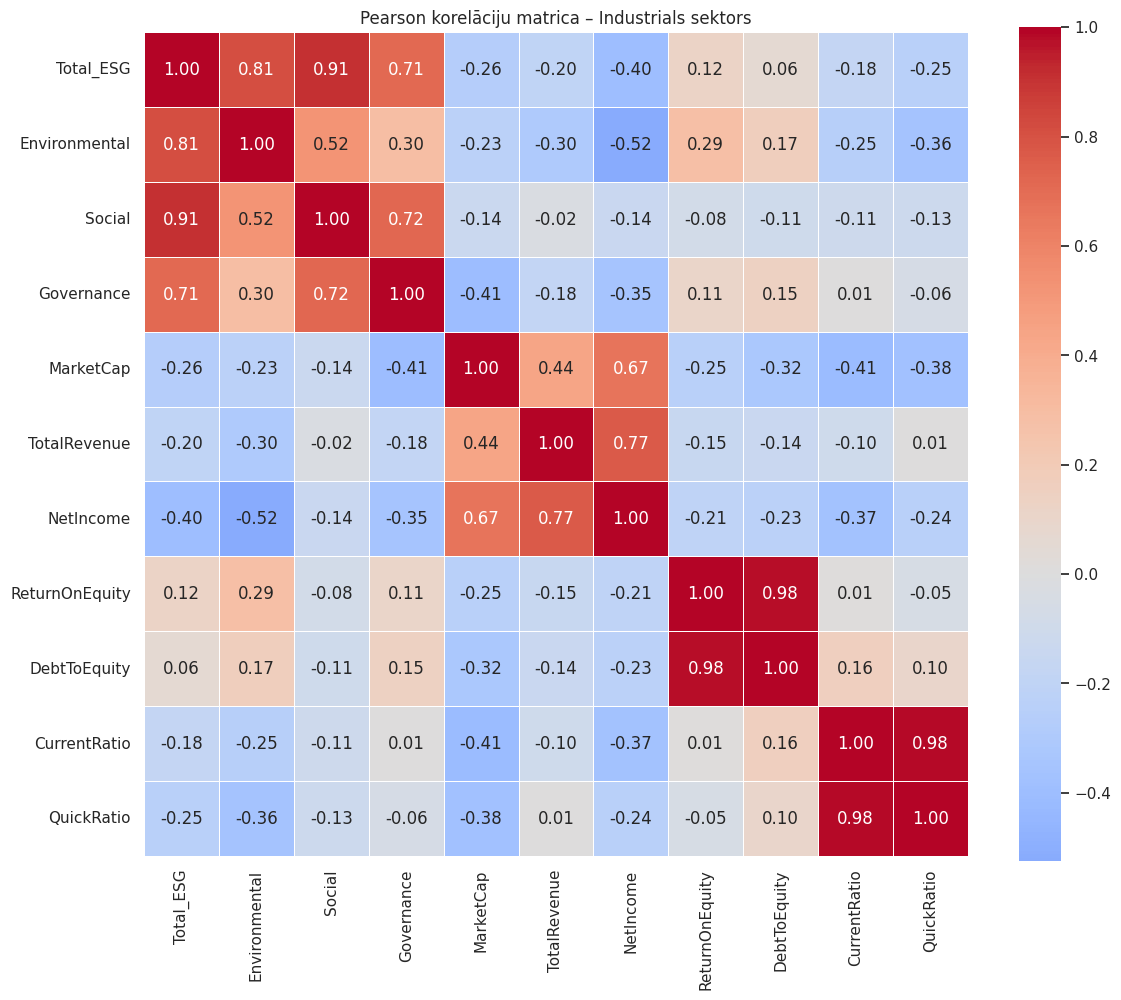

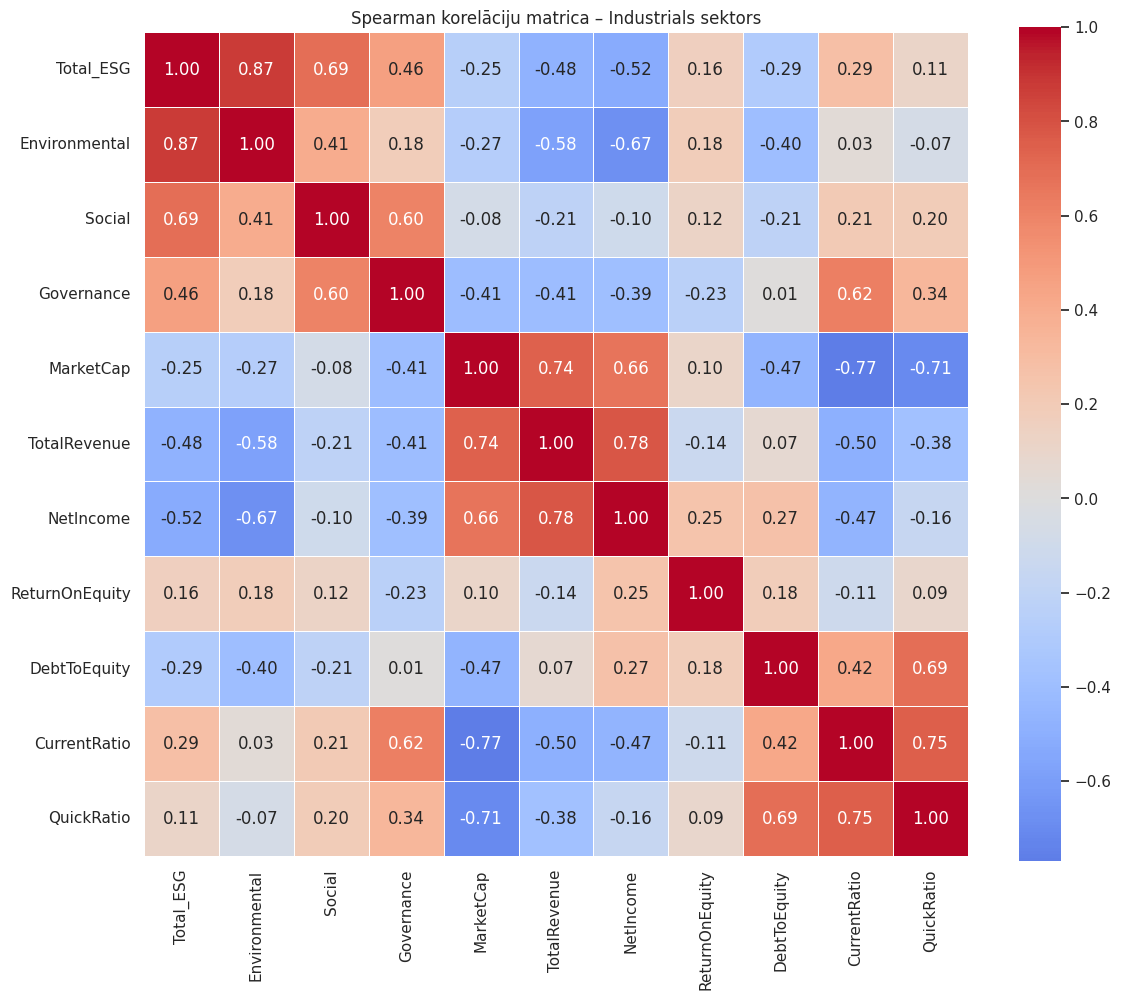

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

df = pd.read_csv("100_company_main.csv")

# Filtrējam Industrials
df_ind = df[df["Sector"] == "Industrials"]

print("Industrials uzņēmumu skaits:", df_ind.shape[0])

cols = [
    "Total_ESG",
    "Environmental",
    "Social",
    "Governance",
    "MarketCap",
    "TotalRevenue",
    "NetIncome",
    "ReturnOnEquity",
    "DebtToEquity",
    "CurrentRatio",
    "QuickRatio"
]

# Pearson
pearson_ind = df_ind[cols].corr(method="pearson")

plt.figure(figsize=(12,10))
sns.heatmap(
    pearson_ind,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Pearson korelāciju matrica – Industrials sektors")
plt.tight_layout()
plt.savefig("industrials_correlation_pearson.pdf", format="pdf", bbox_inches="tight")
plt.show()


# Spearman
spearman_ind = df_ind[cols].corr(method="spearman")

plt.figure(figsize=(12,10))
sns.heatmap(
    spearman_ind,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Spearman korelāciju matrica – Industrials sektors")
plt.tight_layout()
plt.savefig("industrials_correlation_spearman.pdf", format="pdf", bbox_inches="tight")
plt.show()


Modeling

Clustering uz ESG Komponentēm

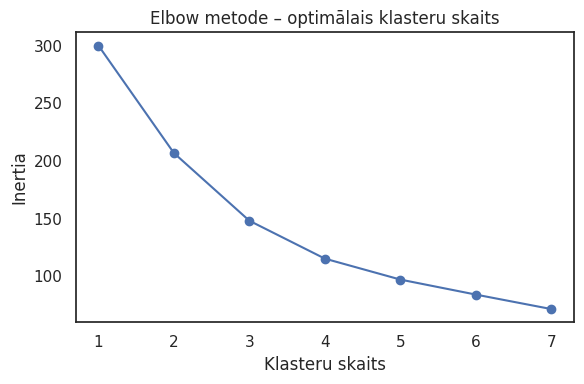

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("100_company_main.csv")

# Izvēlamies ESG komponentes
X = df[["Environmental", "Social", "Governance"]]

# Standartizācija
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow metode
inertia = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow metode – optimālais klasteru skaits")
plt.xlabel("Klasteru skaits")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["ESG_cluster"] = kmeans.fit_predict(X_scaled)

print("\n=== Klasteru lielumi ===")
print(df["ESG_cluster"].value_counts())



=== Klasteru lielumi ===
ESG_cluster
2    50
0    35
1    15
Name: count, dtype: int64


In [ ]:
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers, columns=["Environmental", "Social", "Governance"])

print("\n=== Klasteru centri (oriģinālajās vienībās) ===")
print(centers_df.round(2))



=== Klasteru centri (oriģinālajās vienībās) ===
   Environmental  Social  Governance
0           2.37    9.50        7.20
1          14.39    9.85        4.93
2           5.43    5.50        3.96


In [ ]:
print("\n=== Klasteri pa sektoriem ===")
print(pd.crosstab(df["ESG_cluster"], df["Sector"]))



=== Klasteri pa sektoriem ===
Sector       Basic Materials  Communication Services  Consumer Cyclical  \
ESG_cluster                                                               
0                          0                       6                  5   
1                          3                       0                  2   
2                          4                       0                  8   

Sector       Consumer Defensive  Energy  Financial Services  Healthcare  \
ESG_cluster                                                               
0                             2       0                  10           7   
1                             1       3                   0           0   
2                             1       0                   2           5   

Sector       Industrials  Real Estate  Technology  Utilities  
ESG_cluster                                                   
0                      0            1           4          0  
1                      3    

In [ ]:
financial_cols = ["MarketCap", "TotalRevenue", "NetIncome",
                  "ReturnOnEquity", "DebtToEquity",
                  "CurrentRatio", "QuickRatio"]

cluster_financials = df.groupby("ESG_cluster")[financial_cols].mean()

print("\n=== Finanšu profili pa ESG klasteriem ===")
print(cluster_financials.round(2))



=== Finanšu profili pa ESG klasteriem ===
                MarketCap  TotalRevenue     NetIncome  ReturnOnEquity  \
ESG_cluster                                                             
0            6.435288e+10  4.860048e+10  5.985688e+09            0.19   
1            3.332220e+10  2.672828e+10  2.345205e+09            0.58   
2            1.817746e+11  3.403384e+10  4.457282e+09            0.28   

             DebtToEquity  CurrentRatio  QuickRatio  
ESG_cluster                                          
0                   85.33          2.77        1.68  
1                  263.58          1.31        0.88  
2                  132.86          1.72        1.21  


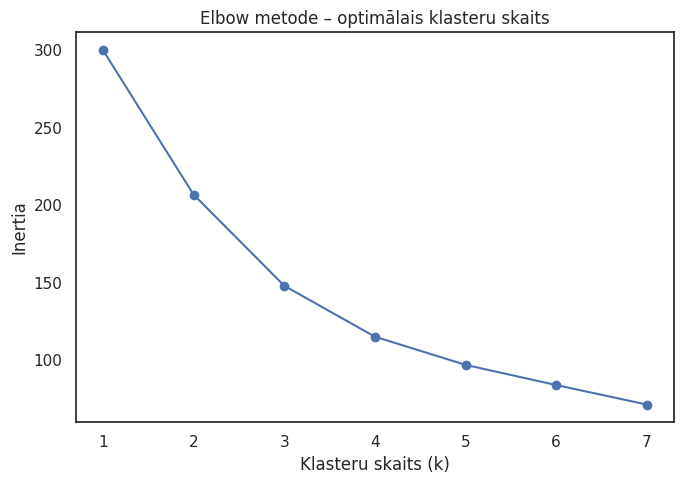

Saglabāts: esg_clustering_elbow.pdf

=== Klasteru lielumi ===
ESG_cluster
2    50
0    35
1    15
Name: count, dtype: int64

=== Klasteru centri (oriģinālajās vienībās) ===
           Environmental  Social  Governance
Cluster 0           2.37    9.50        7.20
Cluster 1          14.39    9.85        4.93
Cluster 2           5.43    5.50        3.96
Saglabāts: esg_clustering_cluster_centers.csv, esg_clustering_cluster_centers.xlsx


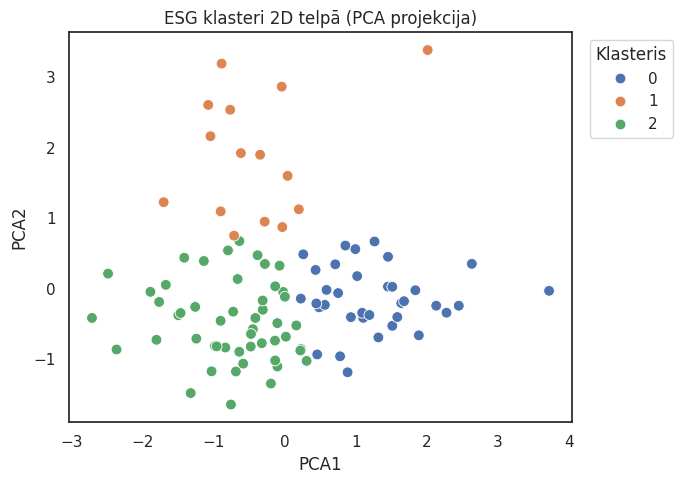

Saglabāts: esg_clustering_pca_scatter.pdf


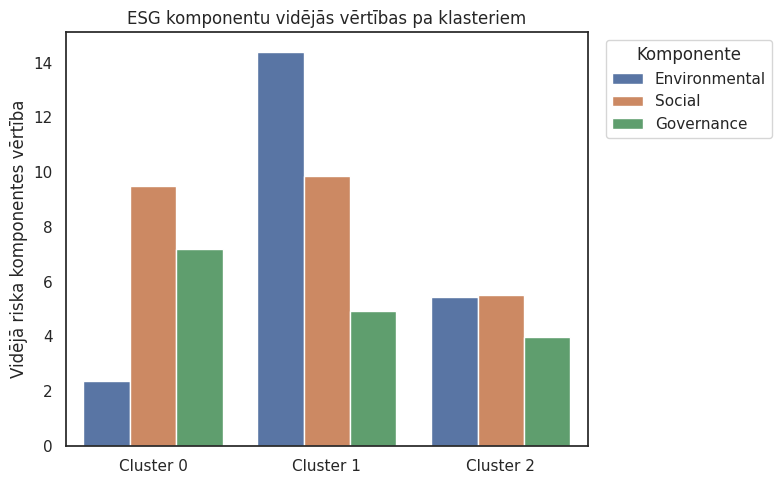

Saglabāts: esg_clustering_cluster_centers_bars.pdf

=== Klasteri pa sektoriem ===
Sector       Basic Materials  Communication Services  Consumer Cyclical  \
ESG_cluster                                                               
0                          0                       6                  5   
1                          3                       0                  2   
2                          4                       0                  8   

Sector       Consumer Defensive  Energy  Financial Services  Healthcare  \
ESG_cluster                                                               
0                             2       0                  10           7   
1                             1       3                   0           0   
2                             1       0                   2           5   

Sector       Industrials  Real Estate  Technology  Utilities  
ESG_cluster                                                   
0                      0            1   

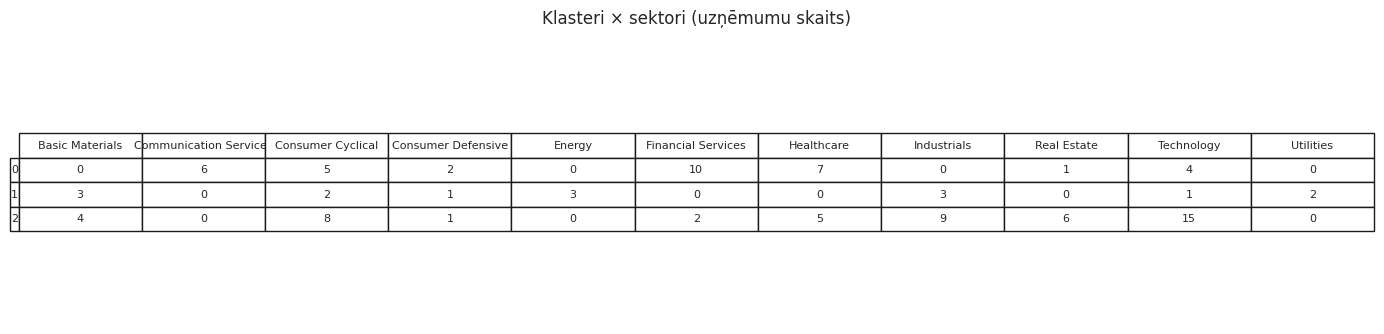

Saglabāts: esg_clustering_cluster_by_sector_table.pdf

=== Finanšu profili pa klasteriem (mean) ===
                MarketCap  TotalRevenue     NetIncome  ReturnOnEquity  \
ESG_cluster                                                             
0            6.435288e+10  4.860048e+10  5.985688e+09        0.193991   
1            3.332220e+10  2.672828e+10  2.345205e+09        0.581411   
2            1.817746e+11  3.403384e+10  4.457282e+09        0.275611   

             DebtToEquity  CurrentRatio  QuickRatio  
ESG_cluster                                          
0               85.329314      2.767029    1.684486  
1              263.580467      1.313267    0.881600  
2              132.858020      1.724120    1.213380  
Saglabāts: esg_clustering_financials_by_cluster.csv, esg_clustering_financials_by_cluster.xlsx


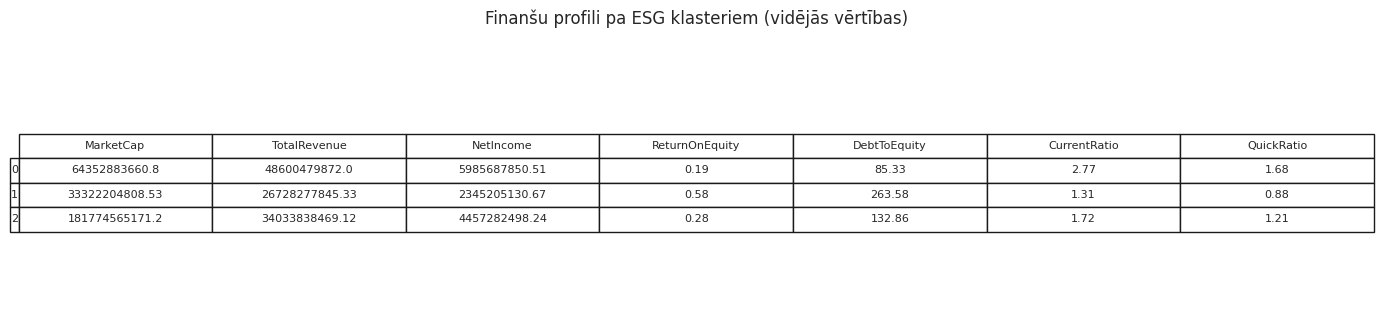

Saglabāts: esg_clustering_financials_by_cluster_table.pdf

✅ Visi PDF/CSV/Excel faili saglabāti darba direktorijā.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="white")

# =========================
# 1) Load data
# =========================
df = pd.read_csv("100_company_main.csv")

esg_cols = ["Environmental", "Social", "Governance"]
X = df[esg_cols].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Output folder (optional)
OUT_PREFIX = "esg_clustering"  # file name prefix

# =========================
# 2) Elbow plot -> PDF
# =========================
inertia = []
K_range = range(1, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(K_range), inertia, marker="o")
plt.title("Elbow metode – optimālais klasteru skaits")
plt.xlabel("Klasteru skaits (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_elbow.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(f"Saglabāts: {OUT_PREFIX}_elbow.pdf")

# =========================
# 3) Fit KMeans (k=3) and save cluster labels
# =========================
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["ESG_cluster"] = kmeans.fit_predict(X_scaled)

print("\n=== Klasteru lielumi ===")
print(df["ESG_cluster"].value_counts())

# Cluster centers in original units
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_orig, columns=esg_cols)
centers_df.index = [f"Cluster {i}" for i in range(k)]

print("\n=== Klasteru centri (oriģinālajās vienībās) ===")
print(centers_df.round(2))

# Save centers to CSV/Excel
centers_df.to_csv(f"{OUT_PREFIX}_cluster_centers.csv")
centers_df.to_excel(f"{OUT_PREFIX}_cluster_centers.xlsx")
print(f"Saglabāts: {OUT_PREFIX}_cluster_centers.csv, {OUT_PREFIX}_cluster_centers.xlsx")

# =========================
# 4) PCA 2D scatter plot -> PDF
# =========================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="ESG_cluster", palette="deep", s=60)
plt.title("ESG klasteri 2D telpā (PCA projekcija)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title="Klasteris", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_pca_scatter.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(f"Saglabāts: {OUT_PREFIX}_pca_scatter.pdf")

# =========================
# 5) Cluster centers bar chart -> PDF
# =========================
centers_long = centers_df.reset_index().melt(id_vars="index", var_name="Komponente", value_name="Vērtība")
centers_long.rename(columns={"index":"Klasteris"}, inplace=True)

plt.figure(figsize=(8,5))
sns.barplot(data=centers_long, x="Klasteris", y="Vērtība", hue="Komponente")
plt.title("ESG komponentu vidējās vērtības pa klasteriem")
plt.xlabel("")
plt.ylabel("Vidējā riska komponentes vērtība")
plt.legend(title="Komponente", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_cluster_centers_bars.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(f"Saglabāts: {OUT_PREFIX}_cluster_centers_bars.pdf")

# =========================
# 6) Cluster x Sector table -> CSV/Excel + PDF
# =========================
cluster_sector = pd.crosstab(df["ESG_cluster"], df["Sector"])
print("\n=== Klasteri pa sektoriem ===")
print(cluster_sector)

cluster_sector.to_csv(f"{OUT_PREFIX}_cluster_by_sector.csv")
cluster_sector.to_excel(f"{OUT_PREFIX}_cluster_by_sector.xlsx")
print(f"Saglabāts: {OUT_PREFIX}_cluster_by_sector.csv, {OUT_PREFIX}_cluster_by_sector.xlsx")

# Save table as PDF (matplotlib table)
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis("off")
tbl = ax.table(
    cellText=cluster_sector.values,
    rowLabels=cluster_sector.index,
    colLabels=cluster_sector.columns,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)
plt.title("Klasteri × sektori (uzņēmumu skaits)", pad=12)
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_cluster_by_sector_table.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(f"Saglabāts: {OUT_PREFIX}_cluster_by_sector_table.pdf")

# =========================
# 7) Financial profiles by cluster -> CSV/Excel + PDF
# =========================
financial_cols = [
    "MarketCap", "TotalRevenue", "NetIncome",
    "ReturnOnEquity", "DebtToEquity", "CurrentRatio", "QuickRatio"
]

cluster_fin = df.groupby("ESG_cluster")[financial_cols].mean()
print("\n=== Finanšu profili pa klasteriem (mean) ===")
print(cluster_fin)

cluster_fin.to_csv(f"{OUT_PREFIX}_financials_by_cluster.csv")
cluster_fin.to_excel(f"{OUT_PREFIX}_financials_by_cluster.xlsx")
print(f"Saglabāts: {OUT_PREFIX}_financials_by_cluster.csv, {OUT_PREFIX}_financials_by_cluster.xlsx")

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis("off")
tbl2 = ax.table(
    cellText=np.round(cluster_fin.values, 2),
    rowLabels=cluster_fin.index,
    colLabels=cluster_fin.columns,
    cellLoc="center",
    loc="center"
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(8)
tbl2.scale(1, 1.4)
plt.title("Finanšu profili pa ESG klasteriem (vidējās vērtības)", pad=12)
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_financials_by_cluster_table.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(f"Saglabāts: {OUT_PREFIX}_financials_by_cluster_table.pdf")

print("\n✅ Visi PDF/CSV/Excel faili saglabāti darba direktorijā.")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.backends.backend_pdf import PdfPages

sns.set(style="white")

# =========================
# Settings
# =========================
DATA_FILE = "100_company_main.csv"
REPORT_PDF = "ESG_Clustering_Report.pdf"
OUT_PREFIX = "esg_clustering"

# =========================
# Load data
# =========================
df = pd.read_csv(DATA_FILE)

esg_cols = ["Environmental", "Social", "Governance"]
X = df[esg_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# Elbow data
# =========================
inertia = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# =========================
# Fit KMeans (k=3)
# =========================
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["ESG_cluster"] = kmeans.fit_predict(X_scaled)

cluster_sizes = df["ESG_cluster"].value_counts().sort_index()

# Cluster centers in original units
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_orig, columns=esg_cols)
centers_df.index = [f"Cluster {i}" for i in range(k)]

# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# Crosstab cluster x sector
cluster_sector = pd.crosstab(df["ESG_cluster"], df["Sector"])

# Financial profiles by cluster
financial_cols = [
    "MarketCap", "TotalRevenue", "NetIncome",
    "ReturnOnEquity", "DebtToEquity", "CurrentRatio", "QuickRatio"
]
cluster_fin = df.groupby("ESG_cluster")[financial_cols].mean()

# =========================
# Helper: add table to PDF page
# =========================
def add_table_page(pdf, title, table_df, fontsize=8, scale_y=1.4, fig_w=14, fig_h=4):
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.set_title(title, pad=12)

    tbl = ax.table(
        cellText=np.round(table_df.values, 2) if np.issubdtype(table_df.values.dtype, np.number) else table_df.values,
        rowLabels=table_df.index,
        colLabels=table_df.columns,
        cellLoc="center",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, scale_y)

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

# =========================
# Build multi-page PDF
# =========================
with PdfPages(REPORT_PDF) as pdf:

    # --- Cover / Summary page ---
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.axis("off")
    text = (
        "ESG klasterēšanas report\n\n"
        f"Datu fails: {DATA_FILE}\n"
        f"Novērojumu skaits: {df.shape[0]}\n"
        f"Klasterēšanas mainīgie: {', '.join(esg_cols)}\n"
        f"Algoritms: K-means (standartizēti dati)\n"
        f"Izvēlētais klasteru skaits: {k}\n\n"
        "Šis PDF satur:\n"
        "1) Elbow grafiku\n"
        "2) Klasteru lielumus\n"
        "3) ESG klasteru centrus (tabula)\n"
        "4) PCA vizualizāciju (2D)\n"
        "5) ESG centru barchart\n"
        "6) Klasteri × sektori (tabula)\n"
        "7) Finanšu profili pa klasteriem (tabula)\n"
    )
    ax.text(0.02, 0.95, text, va="top", fontsize=12)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Elbow plot page ---
    fig = plt.figure(figsize=(7, 5))
    plt.plot(list(K_range), inertia, marker="o")
    plt.title("Elbow metode – optimālais klasteru skaits")
    plt.xlabel("Klasteru skaits (k)")
    plt.ylabel("Inertia")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Cluster sizes page ---
    fig = plt.figure(figsize=(7, 5))
    sns.barplot(x=cluster_sizes.index.astype(str), y=cluster_sizes.values)
    plt.title("ESG klasteru lielumi")
    plt.xlabel("Klasteris")
    plt.ylabel("Uzņēmumu skaits")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Cluster centers table page ---
    add_table_page(
        pdf,
        "Klasteru centri (oriģinālajās vienībās)",
        centers_df.round(2),
        fontsize=10,
        scale_y=1.6,
        fig_w=10,
        fig_h=3.5
    )

    # --- PCA scatter page ---
    fig = plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="ESG_cluster", palette="deep", s=70)
    plt.title("ESG klasteri 2D telpā (PCA projekcija)")
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Klasteris", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Cluster centers bar chart page ---
    centers_long = centers_df.reset_index().melt(id_vars="index", var_name="Komponente", value_name="Vērtība")
    centers_long.rename(columns={"index": "Klasteris"}, inplace=True)

    fig = plt.figure(figsize=(9, 6))
    sns.barplot(data=centers_long, x="Klasteris", y="Vērtība", hue="Komponente")
    plt.title("ESG komponentu vidējās vērtības pa klasteriem")
    plt.xlabel("")
    plt.ylabel("Vidējā riska komponentes vērtība")
    plt.legend(title="Komponente", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Cluster x Sector table page ---
    add_table_page(
        pdf,
        "Klasteri × sektori (uzņēmumu skaits)",
        cluster_sector,
        fontsize=8,
        scale_y=1.4,
        fig_w=16,
        fig_h=4
    )

    # --- Financial profiles table page ---
    add_table_page(
        pdf,
        "Finanšu profili pa ESG klasteriem (vidējās vērtības)",
        cluster_fin.round(2),
        fontsize=8,
        scale_y=1.4,
        fig_w=16,
        fig_h=4
    )

print(f"\n✅ Saglabāts multi-page PDF reports: {REPORT_PDF}")



✅ Saglabāts multi-page PDF reports: ESG_Clustering_Report.pdf


In [ ]:
pd.crosstab(df["ESG_cluster"], df["Region"])


Region,Africa/Middle East,Asia-Pacific,Europe,North America,Other
ESG_cluster,,,,,
0,1,11,8,11,4
1,1,1,2,10,1
2,3,0,18,28,1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.backends.backend_pdf import PdfPages

sns.set(style="white")

DATA_FILE = "100_company_main.csv"
REPORT_PDF = "ESG_Clustering_Report.pdf"

df = pd.read_csv(DATA_FILE)

# --- Drošības labad: ja Region ir tukšs kādam ierakstam ---
df["Region"] = df["Region"].fillna("Unknown")

esg_cols = ["Environmental", "Social", "Governance"]
X = df[esg_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow dati
inertia = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# KMeans (k=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["ESG_cluster"] = kmeans.fit_predict(X_scaled)

cluster_sizes = df["ESG_cluster"].value_counts().sort_index()

# Centri oriģinālajās vienībās
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_orig, columns=esg_cols)
centers_df.index = [f"Cluster {i}" for i in range(k)]

# PCA vizualizācijai
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# Crosstab: Cluster × Sector
cluster_sector = pd.crosstab(df["ESG_cluster"], df["Sector"])

# Crosstab: Cluster × Region
cluster_region = pd.crosstab(df["ESG_cluster"], df["Region"])

print("\n=== Klasteri × Reģioni ===")
print(cluster_region)

# Finanšu profili pa klasteriem
financial_cols = [
    "MarketCap", "TotalRevenue", "NetIncome",
    "ReturnOnEquity", "DebtToEquity", "CurrentRatio", "QuickRatio"
]
cluster_fin = df.groupby("ESG_cluster")[financial_cols].mean()

def add_table_page(pdf, title, table_df, fontsize=8, scale_y=1.4, fig_w=16, fig_h=4):
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    ax.set_title(title, pad=12)

    cell_text = table_df.values
    if np.issubdtype(table_df.values.dtype, np.number):
        cell_text = np.round(table_df.values, 2)

    tbl = ax.table(
        cellText=cell_text,
        rowLabels=table_df.index,
        colLabels=table_df.columns,
        cellLoc="center",
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, scale_y)

    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

with PdfPages(REPORT_PDF) as pdf:

    # Titullapa
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.axis("off")
    ax.text(
        0.02, 0.95,
        "ESG klasterēšanas reports (multi-page PDF)\n\n"
        f"Datu fails: {DATA_FILE}\n"
        f"Novērojumu skaits: {df.shape[0]}\n"
        f"Mainīgie: {', '.join(esg_cols)}\n"
        "Algoritms: K-means (standartizēti dati)\n"
        f"Klasteru skaits: {k}\n",
        va="top", fontsize=12
    )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Elbow
    fig = plt.figure(figsize=(7, 5))
    plt.plot(list(K_range), inertia, marker="o")
    plt.title("Elbow metode – optimālais klasteru skaits")
    plt.xlabel("Klasteru skaits (k)")
    plt.ylabel("Inertia")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Klasteru lielumi
    fig = plt.figure(figsize=(7, 5))
    sns.barplot(x=cluster_sizes.index.astype(str), y=cluster_sizes.values)
    plt.title("ESG klasteru lielumi")
    plt.xlabel("Klasteris")
    plt.ylabel("Uzņēmumu skaits")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Klasteru centri (tabula)
    add_table_page(pdf, "Klasteru centri (oriģinālajās vienībās)", centers_df.round(2),
                   fontsize=10, scale_y=1.6, fig_w=10, fig_h=3.5)

    # PCA scatter
    fig = plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="ESG_cluster", palette="deep", s=70)
    plt.title("ESG klasteri 2D telpā (PCA projekcija)")
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.legend(title="Klasteris", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Centru barchart
    centers_long = centers_df.reset_index().melt(id_vars="index", var_name="Komponente", value_name="Vērtība")
    centers_long.rename(columns={"index": "Klasteris"}, inplace=True)

    fig = plt.figure(figsize=(9, 6))
    sns.barplot(data=centers_long, x="Klasteris", y="Vērtība", hue="Komponente")
    plt.title("ESG komponentu vidējās vērtības pa klasteriem")
    plt.xlabel("")
    plt.ylabel("Vidējā riska komponentes vērtība")
    plt.legend(title="Komponente", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Cluster × Sector (tabula)
    add_table_page(pdf, "Klasteri × sektori (uzņēmumu skaits)", cluster_sector,
                   fontsize=8, scale_y=1.4, fig_w=16, fig_h=4)

    # ✅ Cluster × Region: heatmap lapa
    fig = plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_region, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
    plt.title("Klasteri × reģioni (uzņēmumu skaits)")
    plt.xlabel("Reģions")
    plt.ylabel("ESG klasteris")
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # (ja gribi arī tabulu atsevišķi)
    add_table_page(pdf, "Klasteri × reģioni (tabula)", cluster_region,
                   fontsize=9, scale_y=1.4, fig_w=12, fig_h=4)

    # Finanšu profili (tabula)
    add_table_page(pdf, "Finanšu profili pa ESG klasteriem (vidējās vērtības)", cluster_fin.round(2),
                   fontsize=8, scale_y=1.4, fig_w=16, fig_h=4)

print(f"\n✅ Saglabāts: {REPORT_PDF}")



=== Klasteri × Reģioni ===
Region       Africa/Middle East  Asia-Pacific  Europe  North America  Other
ESG_cluster                                                                
0                             1            11       8             11      4
1                             1             1       2             10      1
2                             3             0      18             28      1

✅ Saglabāts: ESG_Clustering_Report.pdf


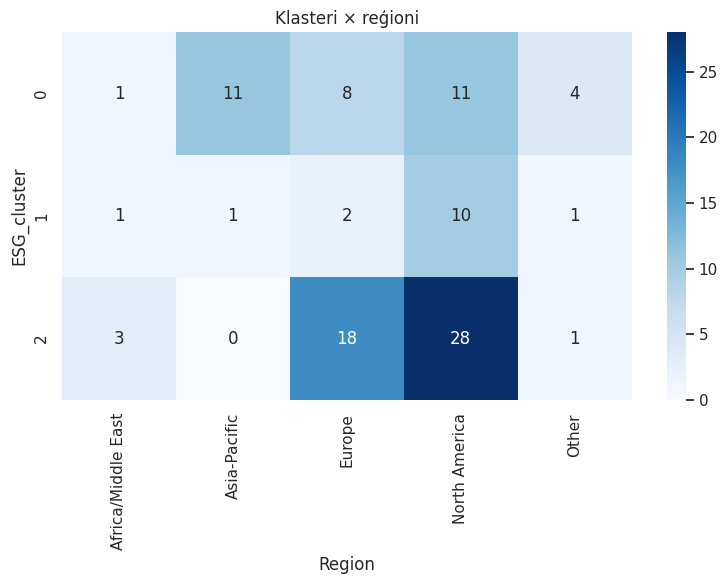

In [ ]:
fig = plt.figure(figsize=(8, 6))

sns.heatmap(cluster_region, annot=True, fmt="d", cmap="Blues")

plt.title("Klasteri × reģioni")
plt.tight_layout()

plt.show()            # <-- parāda terminālī
pdf.savefig(fig)      # <-- saglabā PDF
plt.close(fig)        # <-- aizver figūru


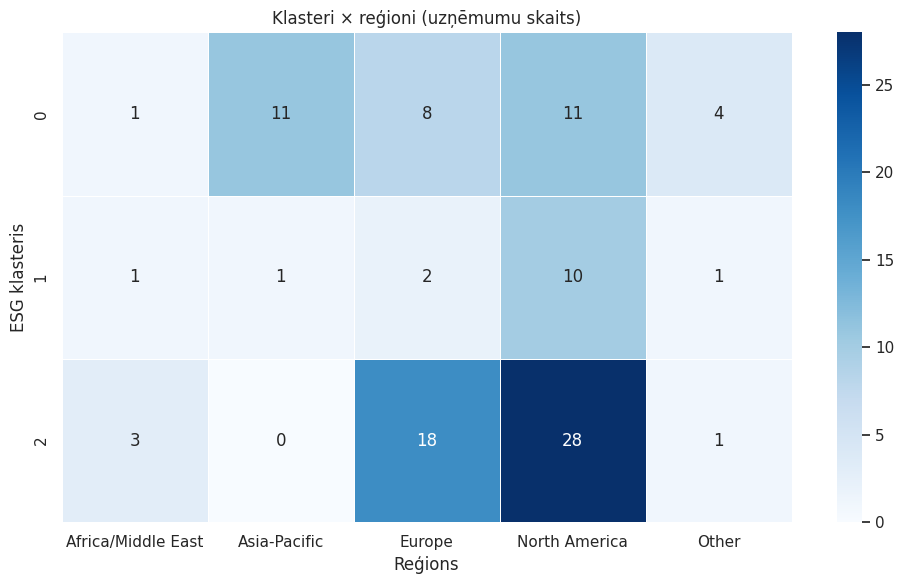

In [ ]:
# --- Cluster × Region heatmap ---
fig = plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_region,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Klasteri × reģioni (uzņēmumu skaits)")
plt.xlabel("Reģions")
plt.ylabel("ESG klasteris")
plt.tight_layout()

plt.show()          # 1️⃣ Rāda notebookā
pdf.savefig(fig)    # 2️⃣ Saglabā PDF
plt.close(fig)


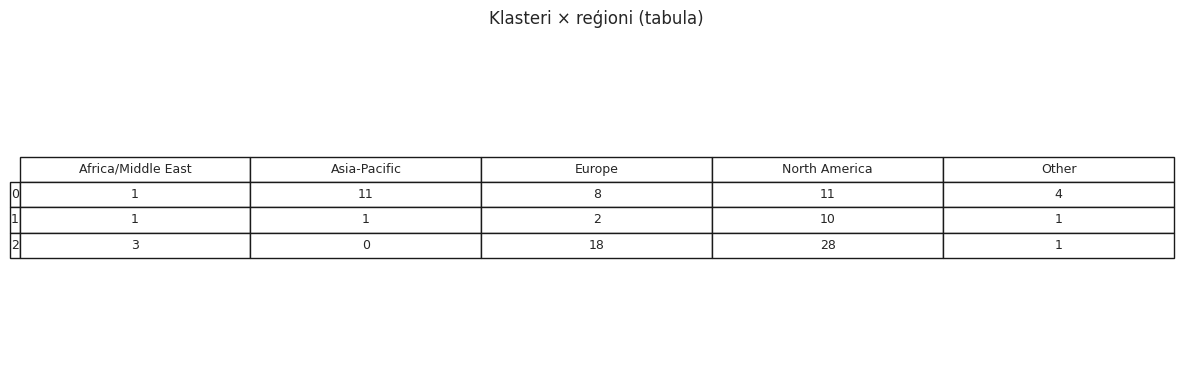

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

tbl = ax.table(
    cellText=cluster_region.values,
    rowLabels=cluster_region.index,
    colLabels=cluster_region.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)

plt.title("Klasteri × reģioni (tabula)", pad=12)
plt.tight_layout()

plt.show()          # <-- parāda
pdf.savefig(fig)    # <-- saglabā
plt.close(fig)


=== ESG klasteru lielumi ===
ESG_cluster
0    35
1    15
2    50
Name: count, dtype: int64


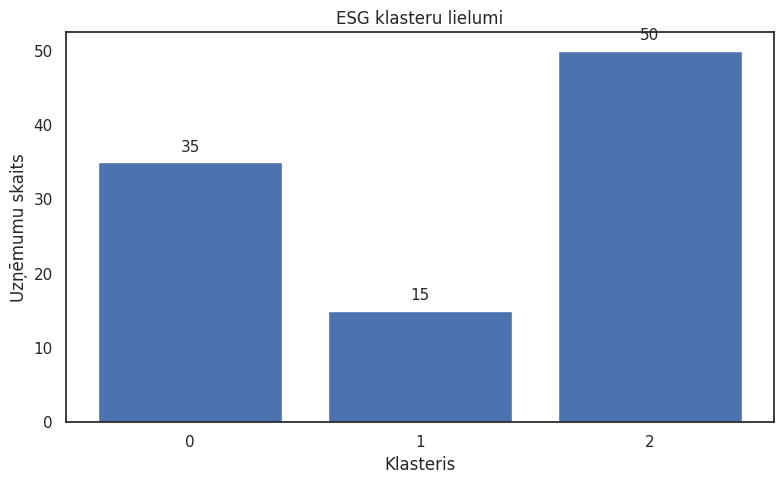

In [ ]:
import matplotlib.pyplot as plt

# Aprēķina klasteru lielumus
cluster_counts = df['ESG_cluster'].value_counts().sort_index()

print("=== ESG klasteru lielumi ===")
print(cluster_counts)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(cluster_counts.index.astype(str),
              cluster_counts.values)

ax.set_title("ESG klasteru lielumi")
ax.set_xlabel("Klasteris")
ax.set_ylabel("Uzņēmumu skaits")

# Pievieno vērtības virs stabiņiem
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 1,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=11)

plt.tight_layout()

# Saglabā PDF
plt.savefig("ESG_cluster_sizes_clean.pdf", bbox_inches='tight')
plt.show()


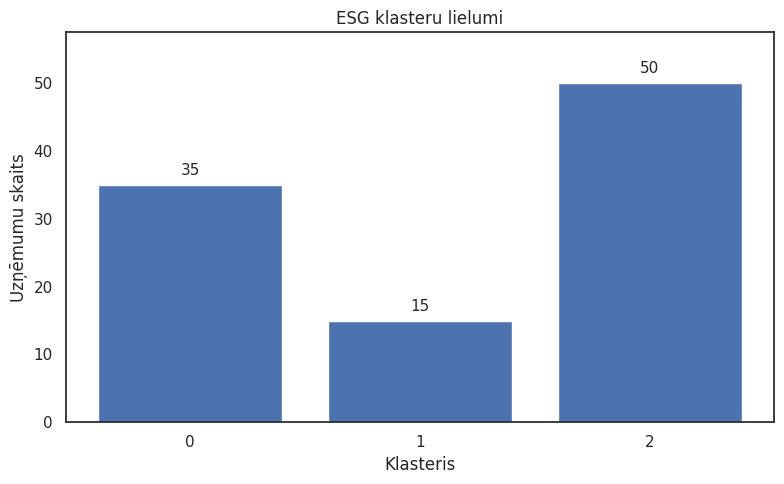

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(cluster_counts.index.astype(str),
              cluster_counts.values)

ax.set_title("ESG klasteru lielumi")
ax.set_xlabel("Klasteris")
ax.set_ylabel("Uzņēmumu skaits")

# Palielina Y robežu
ax.set_ylim(0, cluster_counts.max() * 1.15)

# Skaitļi virs stabiņiem
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 1,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=11)

plt.tight_layout()
plt.show()

# Saglabā PDF
plt.savefig("ESG_cluster_sizes_clean.pdf", bbox_inches='tight')
plt.show()


=== Klasteri × sektori (uzņēmumu skaits) ===
Sector       Basic Materials  Communication Services  Consumer Cyclical  \
ESG_cluster                                                               
0                          0                       6                  5   
1                          3                       0                  2   
2                          4                       0                  8   

Sector       Consumer Defensive  Energy  Financial Services  Healthcare  \
ESG_cluster                                                               
0                             2       0                  10           7   
1                             1       3                   0           0   
2                             1       0                   2           5   

Sector       Industrials  Real Estate  Technology  Utilities  
ESG_cluster                                                   
0                      0            1           4          0  
1            

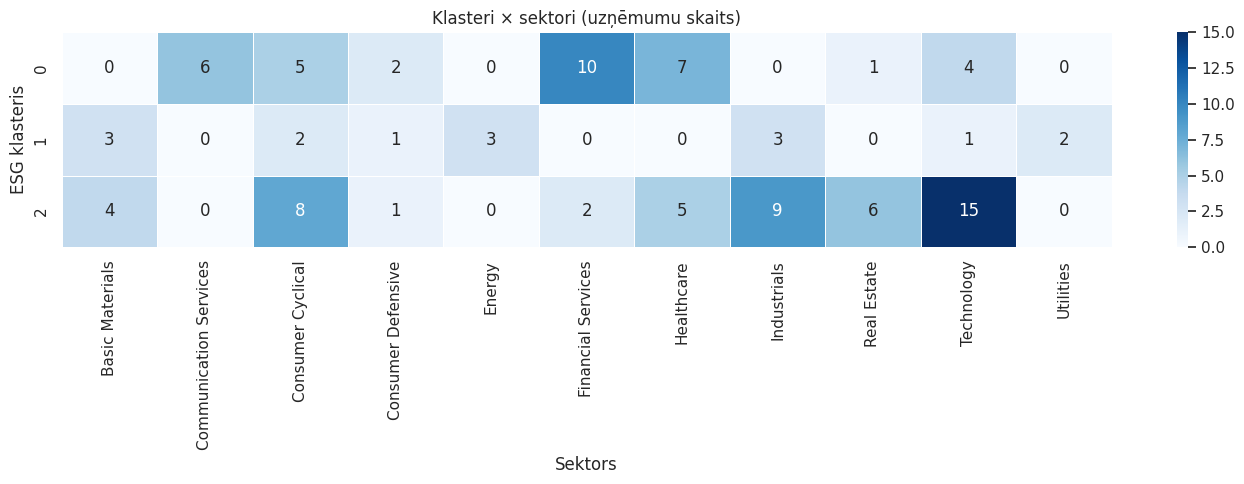

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cluster_sector = pd.crosstab(df["ESG_cluster"], df["Sector"])

print("\n=== Klasteri × sektori (uzņēmumu skaits) ===")
print(cluster_sector)

fig = plt.figure(figsize=(14, 5))
sns.heatmap(cluster_sector, annot=True, fmt="d", cmap="Blues", linewidths=0.5)

plt.title("Klasteri × sektori (uzņēmumu skaits)")
plt.xlabel("Sektors")
plt.ylabel("ESG klasteris")
plt.tight_layout()

plt.show()
pdf.savefig(fig, bbox_inches="tight")
plt.close(fig)



=== Klasteri × sektori (% klastera ietvaros) ===
Sector       Basic Materials  Communication Services  Consumer Cyclical  \
ESG_cluster                                                               
0                        0.0                    17.1               14.3   
1                       20.0                     0.0               13.3   
2                        8.0                     0.0               16.0   

Sector       Consumer Defensive  Energy  Financial Services  Healthcare  \
ESG_cluster                                                               
0                           5.7     0.0                28.6        20.0   
1                           6.7    20.0                 0.0         0.0   
2                           2.0     0.0                 4.0        10.0   

Sector       Industrials  Real Estate  Technology  Utilities  
ESG_cluster                                                   
0                    0.0          2.9        11.4        0.0  
1        

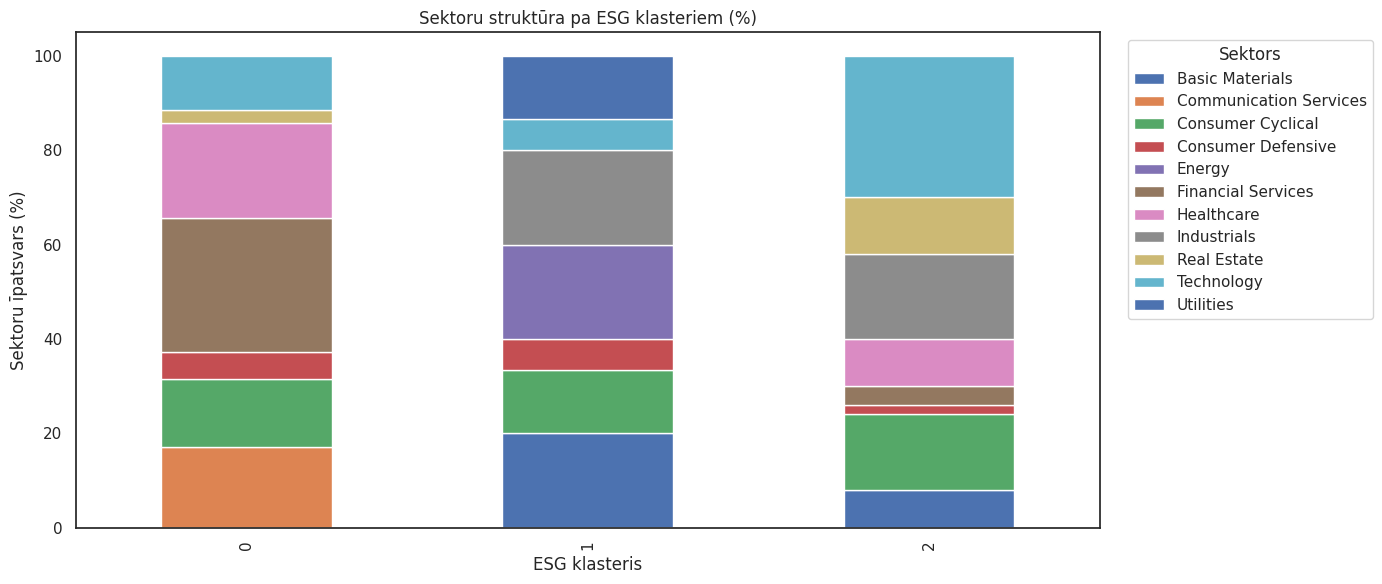

In [ ]:
cluster_sector = pd.crosstab(df["ESG_cluster"], df["Sector"])

# procenti klastera ietvaros (rindas summējas līdz 100%)
cluster_sector_pct = cluster_sector.div(cluster_sector.sum(axis=1), axis=0) * 100

print("\n=== Klasteri × sektori (% klastera ietvaros) ===")
print(cluster_sector_pct.round(1))

fig, ax = plt.subplots(figsize=(14, 6))
cluster_sector_pct.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Sektoru struktūra pa ESG klasteriem (%)")
ax.set_xlabel("ESG klasteris")
ax.set_ylabel("Sektoru īpatsvars (%)")
ax.legend(title="Sektors", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()
pdf.savefig(fig, bbox_inches="tight")
plt.close(fig)



=== ESG komponentu vidējās vērtības pa klasteriem ===
             Environmental  Social  Governance
ESG_cluster                                   
0                     2.37    9.50        7.20
1                    14.39    9.85        4.93
2                     5.43    5.50        3.96

=== Klasteri × sektori (uzņēmumu skaits) ===
Sector       Basic Materials  Communication Services  Consumer Cyclical  \
ESG_cluster                                                               
0                          0                       6                  5   
1                          3                       0                  2   
2                          4                       0                  8   

Sector       Consumer Defensive  Energy  Financial Services  Healthcare  \
ESG_cluster                                                               
0                             2       0                  10           7   
1                             1       3                   0    

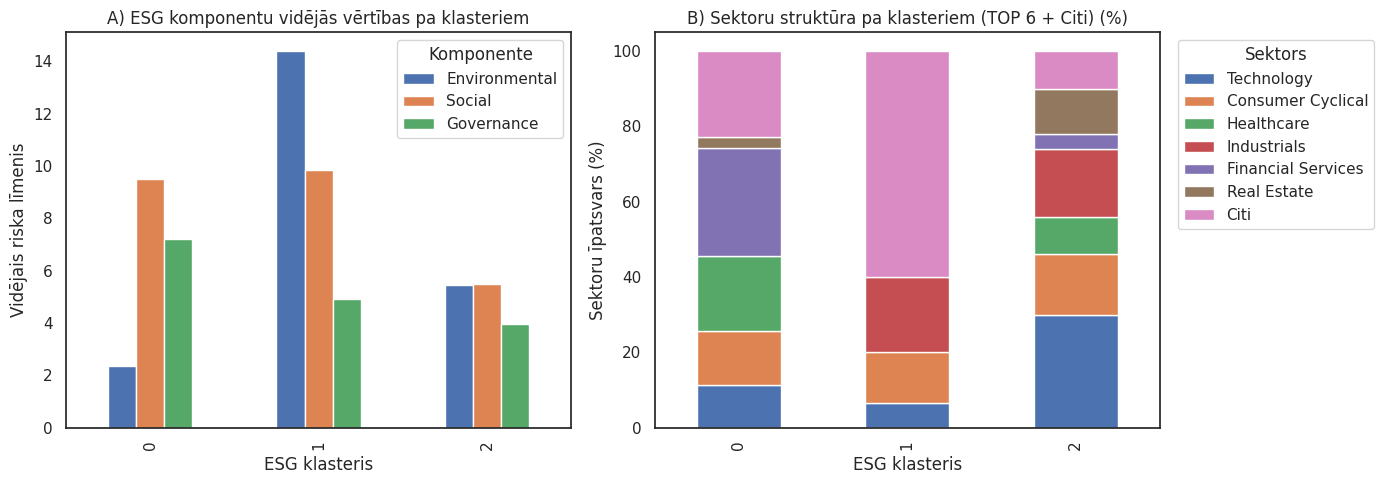

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) ESG klasteru centri (oriģinālajās vienībās) – ja Tev jau ir centers_df, šo var izlaist
# Pieņemam, ka Tev ir df ar ESG_cluster un kolonnām Environmental/Social/Governance
esg_cols = ["Environmental", "Social", "Governance"]
centers_df = df.groupby("ESG_cluster")[esg_cols].mean().sort_index()

print("\n=== ESG komponentu vidējās vērtības pa klasteriem ===")
print(centers_df.round(2))

# -----------------------------
# 2) Klasteri × sektori
cluster_sector = pd.crosstab(df["ESG_cluster"], df["Sector"]).sort_index()

print("\n=== Klasteri × sektori (uzņēmumu skaits) ===")
print(cluster_sector)

# TOP N sektori + Citi (procentos)
TOP_N = 6
top_sectors = cluster_sector.sum(axis=0).sort_values(ascending=False).head(TOP_N).index

cluster_sector_top = cluster_sector[top_sectors].copy()
cluster_sector_top["Citi"] = cluster_sector.drop(columns=top_sectors).sum(axis=1)

cluster_sector_top_pct = cluster_sector_top.div(cluster_sector_top.sum(axis=1), axis=0) * 100

print(f"\n=== Klasteri × sektori (TOP {TOP_N} + Citi) % klastera ietvaros ===")
print(cluster_sector_top_pct.round(1))

# -----------------------------
# 3) Kompozīta vizualizācija (2 paneļi vienā lapā)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A) ESG profili pa klasteriem (grouped bar)
centers_df.plot(kind="bar", ax=axes[0])
axes[0].set_title("A) ESG komponentu vidējās vērtības pa klasteriem")
axes[0].set_xlabel("ESG klasteris")
axes[0].set_ylabel("Vidējais riska līmenis")
axes[0].legend(title="Komponente")

# B) Sektoru struktūra (%)
cluster_sector_top_pct.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title(f"B) Sektoru struktūra pa klasteriem (TOP {TOP_N} + Citi) (%)")
axes[1].set_xlabel("ESG klasteris")
axes[1].set_ylabel("Sektoru īpatsvars (%)")
axes[1].legend(title="Sektors", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Ja Tev ir atvērts PdfPages kā "pdf", tad saglabā:
# pdf.savefig(fig, bbox_inches="tight")

plt.close(fig)



=== ESG komponentu vidējās vērtības pa klasteriem ===
             Environmental  Social  Governance
ESG_cluster                                   
0                     2.37    9.50        7.20
1                    14.39    9.85        4.93
2                     5.43    5.50        3.96


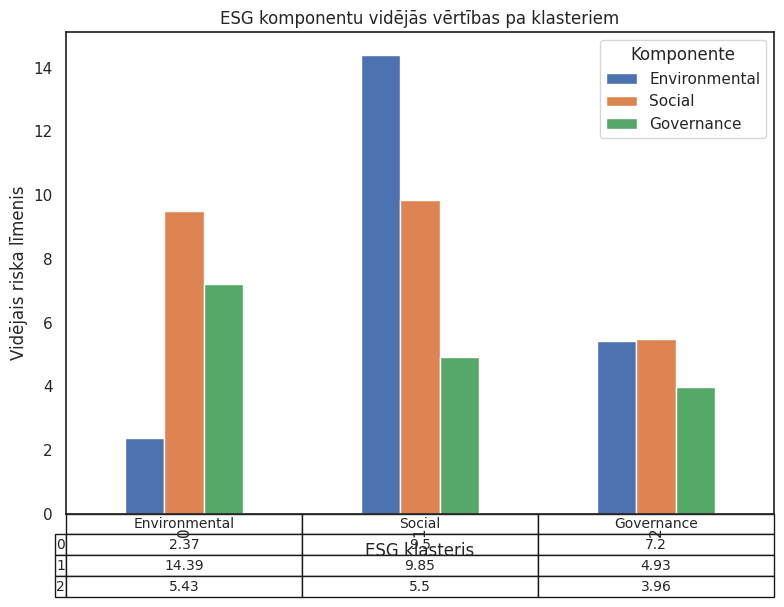

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ESG komponentu vidējās vērtības
esg_cols = ["Environmental", "Social", "Governance"]
centers_df = df.groupby("ESG_cluster")[esg_cols].mean().sort_index()

print("\n=== ESG komponentu vidējās vērtības pa klasteriem ===")
print(centers_df.round(2))

fig, ax = plt.subplots(figsize=(8, 6))

# Grafiks
centers_df.plot(kind="bar", ax=ax)
ax.set_title("ESG komponentu vidējās vērtības pa klasteriem")
ax.set_xlabel("ESG klasteris")
ax.set_ylabel("Vidējais riska līmenis")
ax.legend(title="Komponente")

# Tabula zem grafika
table = plt.table(cellText=centers_df.round(2).values,
                  colLabels=centers_df.columns,
                  rowLabels=centers_df.index,
                  loc='bottom',
                  cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.2)

plt.subplots_adjust(left=0.2, bottom=0.3)

plt.tight_layout()
plt.savefig("ESG_cluster_profiles_with_table.pdf", bbox_inches="tight")
plt.show()


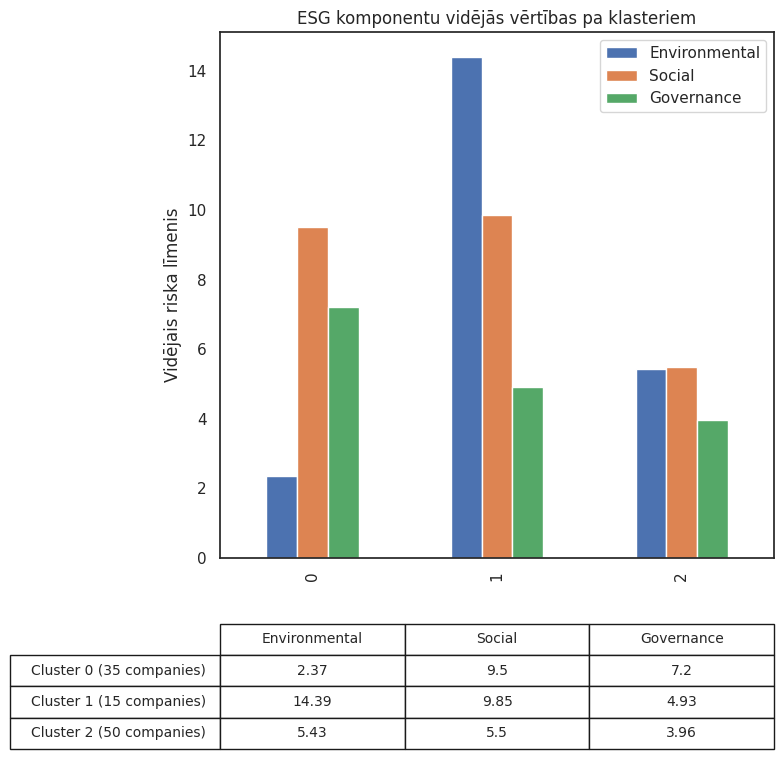

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

esg_cols = ["Environmental", "Social", "Governance"]
centers_df = df.groupby("ESG_cluster")[esg_cols].mean().sort_index()

# Aprēķinām klasteru lielumus
cluster_counts = df['ESG_cluster'].value_counts().sort_index()

# Izveidojam jaunas rindu etiķetes, iekļaujot uzņēmumu skaitu
cluster_labels_with_counts = [f"Cluster {i} ({cluster_counts.get(i, 0)} companies)" for i in centers_df.index]

fig = plt.figure(figsize=(8,8))
gs = GridSpec(2,1, height_ratios=[3,1])

# --- Grafiks ---
ax1 = fig.add_subplot(gs[0])
centers_df.plot(kind="bar", ax=ax1)
ax1.set_title("ESG komponentu vidējās vērtības pa klasteriem")
ax1.set_ylabel("Vidējais riska līmenis")
ax1.set_xlabel("")

# --- Tabula ---
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')

table = ax2.table(
    cellText=centers_df.round(2).values,
    colLabels=centers_df.columns,
    rowLabels=cluster_labels_with_counts, # Izmantojam jaunās etiķetes ar uzņēmumu skaitu
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1,1.5)

plt.tight_layout()
plt.show()

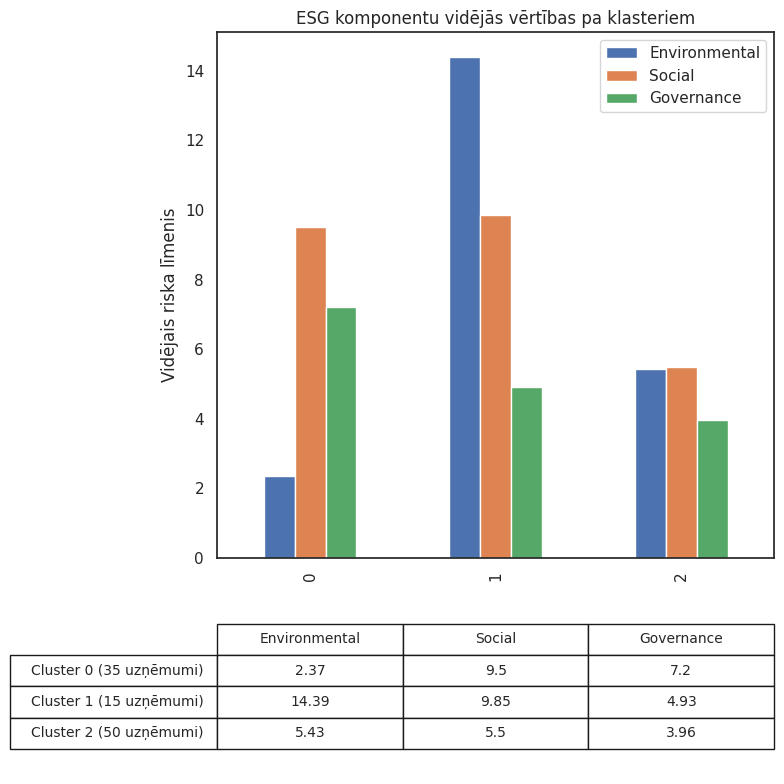

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

esg_cols = ["Environmental", "Social", "Governance"]
centers_df = df.groupby("ESG_cluster")[esg_cols].mean().sort_index()

# Aprēķinām klasteru lielumus
cluster_counts = df['ESG_cluster'].value_counts().sort_index()

# Izveidojam jaunas rindu etiķetes, iekļaujot uzņēmumu skaitu
cluster_labels_with_counts = [f"Cluster {i} ({cluster_counts.get(i, 0)} uzņēmumi)" for i in centers_df.index]

fig = plt.figure(figsize=(8,8))
gs = GridSpec(2,1, height_ratios=[3,1])

# --- Grafiks ---
ax1 = fig.add_subplot(gs[0])
centers_df.plot(kind="bar", ax=ax1)
ax1.set_title("ESG komponentu vidējās vērtības pa klasteriem")
ax1.set_ylabel("Vidējais riska līmenis")
ax1.set_xlabel("")

# --- Tabula ---
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')

table = ax2.table(
    cellText=centers_df.round(2).values,
    colLabels=centers_df.columns,
    rowLabels=cluster_labels_with_counts, # Izmantojam jaunās etiķetes ar uzņēmumu skaitu
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1,1.5)

plt.tight_layout()
plt.show()


=== Klasteri × sektori (uzņēmumu skaits) ===
Sector       Basic Materials  Communication Services  Consumer Cyclical  \
ESG_cluster                                                               
0                          0                       6                  5   
1                          3                       0                  2   
2                          4                       0                  8   

Sector       Consumer Defensive  Energy  Financial Services  Healthcare  \
ESG_cluster                                                               
0                             2       0                  10           7   
1                             1       3                   0           0   
2                             1       0                   2           5   

Sector       Industrials  Real Estate  Technology  Utilities  
ESG_cluster                                                   
0                      0            1           4          0  
1            

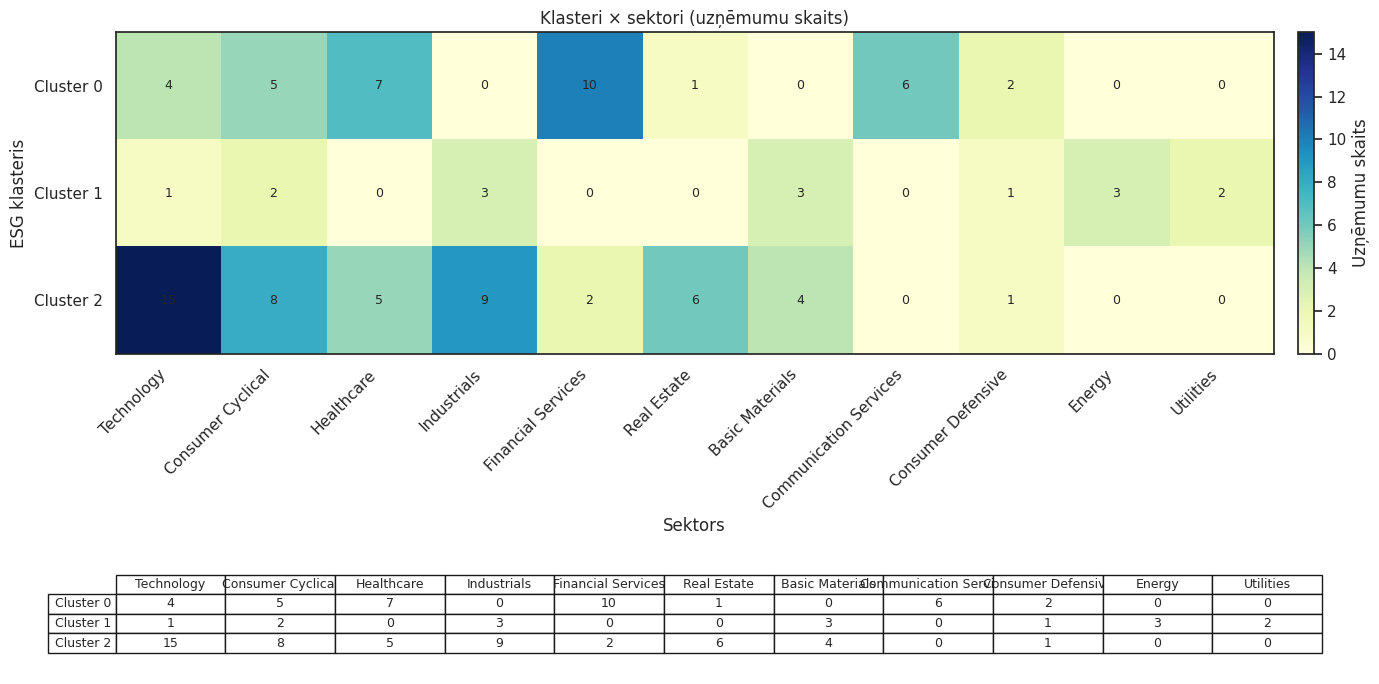

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# 1) Crosstab (absolūtie skaiti)
cluster_sector = pd.crosstab(df["ESG_cluster"], df["Sector"]).sort_index()

print("\n=== Klasteri × sektori (uzņēmumu skaits) ===")
print(cluster_sector)

# (neobligāti) sakārto sektorus pēc kopējā biežuma, lai būtu lasāmāk
sector_order = cluster_sector.sum(axis=0).sort_values(ascending=False).index
cluster_sector = cluster_sector[sector_order]

# 2) Figūra ar heatmap + tabulu
fig = plt.figure(figsize=(14, 7))
gs = GridSpec(2, 1, height_ratios=[3.2, 1.2])

# --- Heatmap ---
ax1 = fig.add_subplot(gs[0])
im = ax1.imshow(cluster_sector.values, aspect='auto', cmap='YlGnBu') # Nomainīta krāsu palete

ax1.set_title("Klasteri × sektori (uzņēmumu skaits)")
ax1.set_xlabel("Sektors")
ax1.set_ylabel("ESG klasteris")

ax1.set_xticks(range(len(cluster_sector.columns)))
ax1.set_xticklabels(cluster_sector.columns, rotation=45, ha="right")
ax1.set_yticks(range(len(cluster_sector.index)))
ax1.set_yticklabels([f"Cluster {i}" for i in cluster_sector.index])

# skaitļi heatmap šūnās
for i in range(cluster_sector.shape[0]):
    for j in range(cluster_sector.shape[1]):
        ax1.text(j, i, int(cluster_sector.values[i, j]),
                 ha='center', va='center', fontsize=9)

# colorbar
cbar = fig.colorbar(im, ax=ax1, fraction=0.02, pad=0.02)
cbar.set_label("Uzņēmumu skaits")

# --- Tabula ---
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")

table = ax2.table(
    cellText=cluster_sector.values,
    rowLabels=[f"Cluster {i}" for i in cluster_sector.index],
    colLabels=cluster_sector.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

plt.tight_layout()
plt.savefig("cluster_sector_heatmap_table.pdf", bbox_inches="tight")
plt.show()

In [ ]:
cluster_sector = pd.crosstab(df["ESG_cluster"], df["Sector"]).sort_index()

# TOP 3 sektori katrā klasterī
topN = 3
top_sectors_per_cluster = (
    cluster_sector.apply(lambda row: row.sort_values(ascending=False).head(topN), axis=1)
)

print("\n=== TOP sektori katrā klasterī (skaits) ===")
for c in top_sectors_per_cluster.index:
    print(f"\nCluster {c}:")
    print(top_sectors_per_cluster.loc[c])

# pārtaisa uz tabulu
rows = []
for c in top_sectors_per_cluster.index:
    for sector, cnt in top_sectors_per_cluster.loc[c].items():
        # Aizstājam NaN ar 0 pirms pārvēršanas par int
        rows.append([f"Cluster {c}", sector, int(cnt if pd.notna(cnt) else 0)])

top_table = pd.DataFrame(rows, columns=["Klasteris", "Sektors", "Uzņēmumu skaits"])

# saglabā Excel/CSV, ja vajag
top_table.to_excel("top_sectors_per_cluster.xlsx", index=False)
top_table.to_csv("top_sectors_per_cluster.csv", index=False)

top_table


=== TOP sektori katrā klasterī (skaits) ===

Cluster 0:
Sector
Basic Materials            NaN
Communication Services     6.0
Consumer Cyclical          NaN
Energy                     NaN
Financial Services        10.0
Healthcare                 7.0
Industrials                NaN
Technology                 NaN
Name: 0, dtype: float64

Cluster 1:
Sector
Basic Materials           3.0
Communication Services    NaN
Consumer Cyclical         NaN
Energy                    3.0
Financial Services        NaN
Healthcare                NaN
Industrials               3.0
Technology                NaN
Name: 1, dtype: float64

Cluster 2:
Sector
Basic Materials            NaN
Communication Services     NaN
Consumer Cyclical          8.0
Energy                     NaN
Financial Services         NaN
Healthcare                 NaN
Industrials                9.0
Technology                15.0
Name: 2, dtype: float64


,Klasteris,Sektors,Uzņēmumu skaits
0,Cluster 0,Basic Materials,0
1,Cluster 0,Communication Services,6
2,Cluster 0,Consumer Cyclical,0
3,Cluster 0,Energy,0
4,Cluster 0,Financial Services,10
5,Cluster 0,Healthcare,7
6,Cluster 0,Industrials,0
7,Cluster 0,Technology,0
8,Cluster 1,Basic Materials,3
9,Cluster 1,Communication Services,0



=== Finanšu rādītāju vidējās vērtības pa ESG klasteriem ===
                MarketCap  DebtToEquity  CurrentRatio  QuickRatio  \
ESG_cluster                                                         
0            6.435288e+10         85.33          2.77        1.68   
1            3.332220e+10        263.58          1.31        0.88   
2            1.817746e+11        132.86          1.72        1.21   

             ReturnOnEquity  
ESG_cluster                  
0                      0.19  
1                      0.58  
2                      0.28  


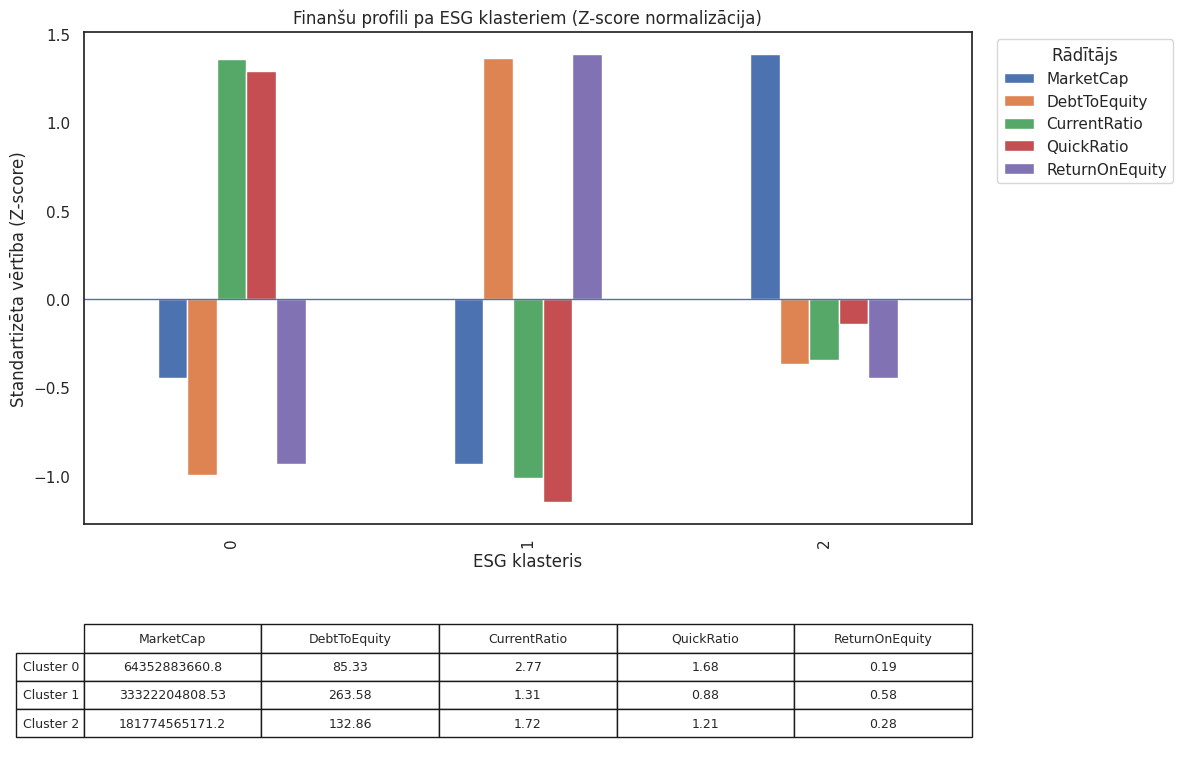

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# 1) Definē finanšu rādītājus
fin_cols = ["MarketCap", "DebtToEquity", "CurrentRatio", "QuickRatio", "ReturnOnEquity"]

# 2) Aprēķina vidējās vērtības pa klasteriem (oriģinālajās vienībās)
fin_means = df.groupby("ESG_cluster")[fin_cols].mean().sort_index()

print("\n=== Finanšu rādītāju vidējās vērtības pa ESG klasteriem ===")
print(fin_means.round(2))

# 3) Z-score normalizācija vizualizācijai (salīdzināmība)
fin_means_z = (fin_means - fin_means.mean()) / fin_means.std(ddof=0)

# 4) Figūra: augšā grafiks, apakšā tabula
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 1, height_ratios=[3.2, 1.2])

# --- A) Normalizēts grafiks ---
ax1 = fig.add_subplot(gs[0])
fin_means_z.plot(kind="bar", ax=ax1)

ax1.set_title("Finanšu profili pa ESG klasteriem (Z-score normalizācija)")
ax1.set_xlabel("ESG klasteris")
ax1.set_ylabel("Standartizēta vērtība (Z-score)")
ax1.axhline(0, linewidth=1)

ax1.legend(title="Rādītājs", bbox_to_anchor=(1.02, 1), loc="upper left")

# --- B) Tabula ar oriģinālajām vērtībām ---
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")

table_df = fin_means.round(2)

table = ax2.table(
    cellText=table_df.values,
    rowLabels=[f"Cluster {i}" for i in table_df.index],
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

plt.tight_layout()
plt.savefig("financial_profiles_by_clusters.pdf", bbox_inches="tight")
plt.show()



=== Finanšu rādītāju vidējās vērtības pa ESG klasteriem (MarketCap miljardos) ===
             MarketCap  TotalRevenue  NetIncome  ReturnOnEquity  DebtToEquity  \
ESG_cluster                                                                     
0                64.35         48.60       5.99            0.19         85.33   
1                33.32         26.73       2.35            0.58        263.58   
2               181.77         34.03       4.46            0.28        132.86   

             CurrentRatio  QuickRatio  
ESG_cluster                            
0                    2.77        1.68  
1                    1.31        0.88  
2                    1.72        1.21  


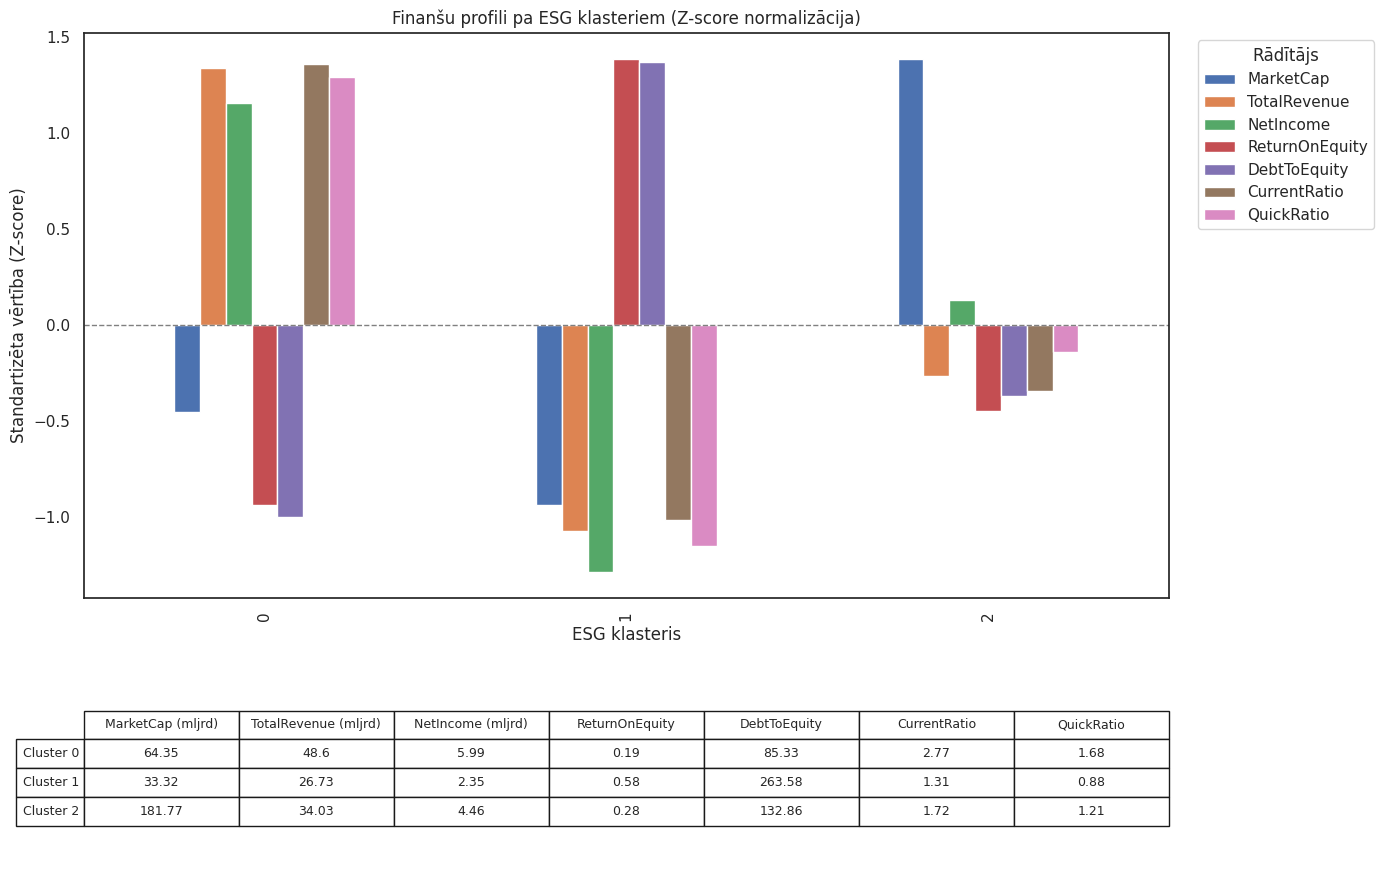

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler

# 1) Definē finanšu rādītājus
fin_cols = ["MarketCap", "TotalRevenue", "NetIncome", "ReturnOnEquity", "DebtToEquity", "CurrentRatio", "QuickRatio"]

# 2) Aprēķina vidējās vērtības pa klasteriem (oriģinālajās vienībās)
fin_means = df.groupby("ESG_cluster")[fin_cols].mean().sort_index()

# 3) Z-score normalizācija vizualizācijai (salīdzināmība)
scaler = StandardScaler()
fin_means_z = pd.DataFrame(
    scaler.fit_transform(fin_means),
    index=fin_means.index,
    columns=fin_means.columns
)

# 4) Sagatavo tabulu ar oriģinālajām vērtībām, kur MarketCap ir miljardos
table_df = fin_means.copy()
table_df["MarketCap"] = (table_df["MarketCap"] / 1e9).round(2) # Pārrēķina uz miljardiem un noapaļo
table_df["TotalRevenue"] = (table_df["TotalRevenue"] / 1e9).round(2) # Pārrēķina uz miljardiem un noapaļo
table_df["NetIncome"] = (table_df["NetIncome"] / 1e9).round(2) # Pārrēķina uz miljardiem un noapaļo
table_df = table_df.round(2) # Noapaļo pārējās kolonnas

print("\n=== Finanšu rādītāju vidējās vērtības pa ESG klasteriem (MarketCap miljardos) ===")
print(table_df)

# 5) Figūra: augšā grafiks, apakšā tabula
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 1, height_ratios=[3.2, 1.2])

# --- A) Normalizēts grafiks ---
ax1 = fig.add_subplot(gs[0])
fin_means_z.plot(kind="bar", ax=ax1)

ax1.set_title("Finanšu profili pa ESG klasteriem (Z-score normalizācija)")
ax1.set_xlabel("ESG klasteris")
ax1.set_ylabel("Standartizēta vērtība (Z-score)")
ax1.axhline(0, linewidth=1, color='gray', linestyle='--')

ax1.legend(title="Rādītājs", bbox_to_anchor=(1.02, 1), loc="upper left")

# --- B) Tabula ar oriģinālajām vērtībām (MarketCap miljardos) ---
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")

# Izveidojam jaunas kolonnu etiķetes
new_col_labels = []
for col in table_df.columns:
    if col in ["MarketCap", "TotalRevenue", "NetIncome"]:
        new_col_labels.append(f"{col} (mljrd)")
    else:
        new_col_labels.append(col)

table = ax2.table(
    cellText=table_df.values,
    rowLabels=[f"Cluster {i}" for i in table_df.index],
    colLabels=new_col_labels, # Izmantojam jaunās etiķetes ar norādi par miljardiem
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

plt.tight_layout()
plt.savefig("financial_profiles_by_clusters_with_billions.pdf", bbox_inches="tight")
plt.show()

/tmp/ipython-input-474893778.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([f"Cluster {i}" for i in ct.index])
/tmp/ipython-input-474893778.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


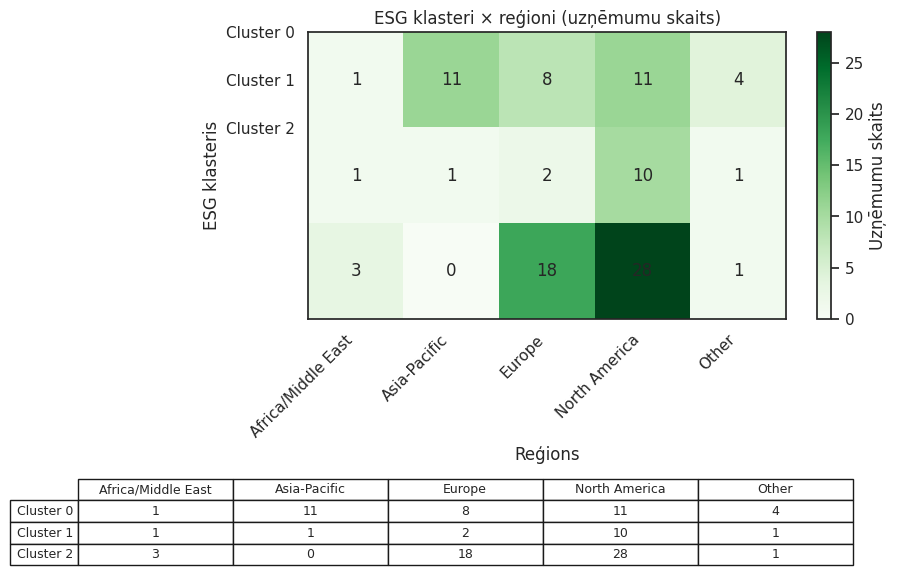


Saglabāts: clusters_x_regions_heatmap_table.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) Crosstab: Klasteri x Reģioni
ct = pd.crosstab(df["ESG_cluster"], df["Region"]) # Labots no company_100_main_df uz df

# (ja gribi noteiktu secību kolonnām)
region_order = ["Africa/Middle East", "Asia-Pacific", "Europe", "North America", "Other"]
ct = ct.reindex(columns=[c for c in region_order if c in ct.columns])

# 2) Viena figūra: heatmap + tabula
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.5, 1.2], hspace=0.8) # Palielināts hspace

# --- Heatmap (augšā) ---
ax1 = fig.add_subplot(gs[0])

data = ct.values
im = ax1.imshow(data, cmap='Greens')  # Nomainīta krāsu palete uz 'Greens'

ax1.set_title("ESG klasteri × reģioni (uzņēmumu skaits)")
ax1.set_xlabel("Reģions")
ax1.set_ylabel("ESG klasteris")

ax1.set_xticks(range(ct.shape[1]))
ax1.set_xticklabels(ct.columns, rotation=45, ha="right")
# Noņemam ax1.set_yticks, jo ax1.set_yticklabels to padarīja lieku un radīja brīdinājumu.
ax1.set_yticklabels([f"Cluster {i}" for i in ct.index])

# skaitļi šūnās
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax1.text(j, i, str(ct.iat[i, j]), ha="center", va="center")

# colorbar
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label("Uzņēmumu skaits")

# --- Tabula (apakšā) ---
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")

table = ax2.table(
    cellText=ct.values,
    rowLabels=[f"Cluster {i}" for i in ct.index], # Mainītas rindu etiķetes
    colLabels=ct.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

plt.tight_layout()
plt.show()

# 3) (opcionāli) saglabāšana PDF
out_pdf = "clusters_x_regions_heatmap_table.pdf"
fig.savefig(out_pdf, bbox_inches="tight")
print(f"\nSaglabāts: {out_pdf}")

/tmp/ipython-input-3606129945.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


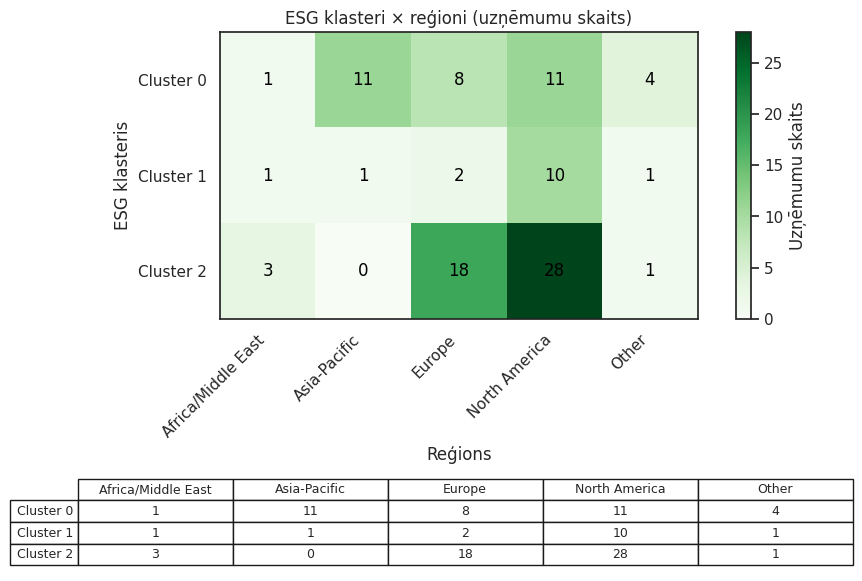

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ct = pd.crosstab(df["ESG_cluster"], # Mainīts no company_100_main_df uz df
                 df["Region"])       # Mainīts no company_100_main_df uz df

region_order = ["Africa/Middle East", "Asia-Pacific", "Europe", "North America", "Other"]
ct = ct.reindex(columns=[c for c in region_order if c in ct.columns])

fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.5, 1.2], hspace=0.8) # Palielināts hspace

# --- Heatmap ---
ax1 = fig.add_subplot(gs[0])

data = ct.values
im = ax1.imshow(data, cmap='Greens')  # Nomainīta krāsu palete uz 'Greens'

ax1.set_title("ESG klasteri × reģioni (uzņēmumu skaits)")
ax1.set_xlabel("Reģions")
ax1.set_ylabel("ESG klasteris")

ax1.set_xticks(np.arange(len(ct.columns)))
ax1.set_xticklabels(ct.columns, rotation=45, ha="right")

ax1.set_yticks(np.arange(len(ct.index)))
ax1.set_yticklabels([f"Cluster {i}" for i in ct.index])

# Apgriežam Y asi, lai klasteris 0 būtu apakšā
# ax1.invert_yaxis() # Šī rinda ir izkomentēta, lai nodrošinātu konsekventu klasteru secību

# Anotācijas
for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        value = ct.iloc[i, j]
        ax1.text(j, i, value, ha="center", va="center", color="black")

cbar = fig.colorbar(im, ax=ax1)
cbar.set_label("Uzņēmumu skaits")

# --- Tabula ---
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")

table = ax2.table(
    cellText=ct.values,
    rowLabels=[f"Cluster {i}" for i in ct.index],
    colLabels=ct.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

plt.tight_layout()
plt.show()